# 02. Limpieza de datos

Este notebook contiene la limpieza del dataset de víctimas del conflicto armado en Colombia.

## Importación de Librerías

Importamos las librerías necesarias para el análisis de datos.

In [1]:
import pandas as pd
import csv
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

## Carga del Dataset

Cargamos el dataset de víctimas del conflicto armado desde el archivo CSV.

In [2]:
# Define the relative path to the data file
data_path = '../data/raw/victimas_por_hechos_departamental_20250416.csv'

# Load the dataset
try:
    # Attempt to read with UTF-8 encoding first
    df = pd.read_csv(data_path, encoding='utf-8') 
except UnicodeDecodeError:
    try:
        # Fallback to Latin-1 encoding if UTF-8 fails
        df = pd.read_csv(data_path, encoding='latin1') 
    except Exception as e:
        print(f"Error loading CSV file: {e}")
        df = None # Indicate failure by setting df to None

# Verificar si el dataset se cargó correctamente
if df is not None:
    print(f"Dataset cargado exitosamente. Dimensiones: {df.shape}")
else:
    print("Error al cargar el dataset. Por favor, verifica la ruta y la codificación del archivo.")

Dataset cargado exitosamente. Dimensiones: (2431164, 17)


# Eliminacion de columnas innecesarias
Se eliminaran las columnas que no sean necesarias para el analisis como NOM_RPT, COD_PAI y PAIS

In [4]:
# Mostrar forma inicial del dataframe y vista previa
print(f"Forma inicial del dataframe: {df.shape}")
print(f"Columnas del dataframe: {df.columns.tolist()}")

Forma inicial del dataframe: (2431164, 17)
Columnas del dataframe: ['FECHA_CORTE', 'NOM_RPT', 'COD_PAIS', 'PAIS', 'COD_ESTADO_DEPTO', 'ESTADO_DEPTO', 'PARAM_HECHO', 'HECHO', 'SEXO', 'ETNIA', 'DISCAPACIDAD', 'CICLO_VITAL', 'PER_OCU', 'PER_DECLA', 'PER_UBIC', 'PER_SA', 'EVENTOS']


In [3]:
# Columnas que se eliminarán
# columns_to_drop = ["NOM_RPT", "COD_PAIS", "PAIS", "FECHA_CORTE"]
columns_to_drop = ["NOM_RPT", "COD_PAIS", "PAIS"]

# Eliminar columnas especificadas
df = df.drop(columns=columns_to_drop)

In [7]:
# Mostrar forma final del dataframe
print(f"Forma final del dataframe después de eliminar columnas: {df.shape}")
print(f"Columnas del dataframe: {df.columns.tolist()}")
df.head()

Forma final del dataframe después de eliminar columnas: (2431164, 14)
Columnas del dataframe: ['FECHA_CORTE', 'COD_ESTADO_DEPTO', 'ESTADO_DEPTO', 'PARAM_HECHO', 'HECHO', 'SEXO', 'ETNIA', 'DISCAPACIDAD', 'CICLO_VITAL', 'PER_OCU', 'PER_DECLA', 'PER_UBIC', 'PER_SA', 'EVENTOS']


,FECHA_CORTE,COD_ESTADO_DEPTO,ESTADO_DEPTO,PARAM_HECHO,HECHO,SEXO,ETNIA,DISCAPACIDAD,CICLO_VITAL,PER_OCU,PER_DECLA,PER_UBIC,PER_SA,EVENTOS
0,2022/03/31 00:00:00.000000000,13,Bolivar,5,Desplazamiento forzado,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,3.0,4.0,3.0,3.0,3.0
1,2022/02/28 00:00:00.000000000,20,Cesar,5,Desplazamiento forzado,Mujer,Raizal del Archipielago de San Andres y Provid...,Multiple,entre 61 y 100,1.0,NaN,NaN,NaN,1.0
2,2022/04/30 00:00:00.000000000,18,Caqueta,5,Desplazamiento forzado,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 29 y 60,2.0,NaN,NaN,NaN,2.0
3,2022/05/31 00:00:00.000000000,95,Guaviare,5,Desplazamiento forzado,Hombre,Negro(a) o Afrocolombiano(a),Fisica,entre 61 y 100,11.0,7.0,4.0,4.0,12.0
4,2022/04/30 00:00:00.000000000,18,Caqueta,2,Amenaza,Hombre,Indigena (Acreditado RA),Por Establecer,entre 12 y 17,1.0,1.0,1.0,1.0,1.0


# Detectar patrones en formato de FECHA_CORTE
Acá reemplazamos los digitos de la fecha por "d", asi los patrones se verian mejor

In [4]:
# Supongamos que tu DataFrame se llama df
df["FORMATO_FECHA"] = df["FECHA_CORTE"].astype(str).str.replace(r"\d", "d", regex=True)

# Ver los primeros formatos únicos
print(df["FORMATO_FECHA"].value_counts().head(10))

FORMATO_FECHA
dddd/dd/dd dd:dd:dd.ddddddddd    2048672
dd/dd/dddd                        319076
dd/dd/dd                           63416
Name: count, dtype: int64


In [5]:
df[df["FORMATO_FECHA"] == 'dddd/dd/dd dd:dd:dd.ddddddddd']

,FECHA_CORTE,COD_ESTADO_DEPTO,ESTADO_DEPTO,PARAM_HECHO,HECHO,SEXO,ETNIA,DISCAPACIDAD,CICLO_VITAL,PER_OCU,PER_DECLA,PER_UBIC,PER_SA,EVENTOS,FORMATO_FECHA
0,2022/03/31 00:00:00.000000000,13,Bolivar,5,Desplazamiento forzado,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,3.0,4.0,3.0,3.0,3.0,dddd/dd/dd dd:dd:dd.ddddddddd
1,2022/02/28 00:00:00.000000000,20,Cesar,5,Desplazamiento forzado,Mujer,Raizal del Archipielago de San Andres y Provid...,Multiple,entre 61 y 100,1.0,NaN,NaN,NaN,1.0,dddd/dd/dd dd:dd:dd.ddddddddd
2,2022/04/30 00:00:00.000000000,18,Caqueta,5,Desplazamiento forzado,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 29 y 60,2.0,NaN,NaN,NaN,2.0,dddd/dd/dd dd:dd:dd.ddddddddd
3,2022/05/31 00:00:00.000000000,95,Guaviare,5,Desplazamiento forzado,Hombre,Negro(a) o Afrocolombiano(a),Fisica,entre 61 y 100,11.0,7.0,4.0,4.0,12.0,dddd/dd/dd dd:dd:dd.ddddddddd
4,2022/04/30 00:00:00.000000000,18,Caqueta,2,Amenaza,Hombre,Indigena (Acreditado RA),Por Establecer,entre 12 y 17,1.0,1.0,1.0,1.0,1.0,dddd/dd/dd dd:dd:dd.ddddddddd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2060050,2024/08/31 00:00:00.000000000,17,Caldas,2,Amenaza,Hombre,Negro(a) o Afrocolombiano(a),Por Establecer,entre 60 y 110,1.0,NaN,NaN,NaN,1.0,dddd/dd/dd dd:dd:dd.ddddddddd
2060051,2024/08/31 00:00:00.000000000,76,Valle del Cauca,2,Amenaza,Mujer,Negro(a) o Afrocolombiano(a),Fisica,entre 6 y 11,5.0,14.0,12.0,12.0,5.0,dddd/dd/dd dd:dd:dd.ddddddddd
2060052,2024/08/31 00:00:00.000000000,66,Risaralda,2,Amenaza,Hombre,Indigena,Visual,entre 29 y 59,NaN,1.0,NaN,NaN,NaN,dddd/dd/dd dd:dd:dd.ddddddddd
2060053,2024/08/31 00:00:00.000000000,66,Risaralda,5,Desplazamiento forzado,Hombre,Gitano(a) ROM,Ninguna,entre 18 y 28,1.0,7.0,7.0,6.0,1.0,dddd/dd/dd dd:dd:dd.ddddddddd


In [6]:
df[df["FORMATO_FECHA"] == 'dd/dd/dddd']

,FECHA_CORTE,COD_ESTADO_DEPTO,ESTADO_DEPTO,PARAM_HECHO,HECHO,SEXO,ETNIA,DISCAPACIDAD,CICLO_VITAL,PER_OCU,PER_DECLA,PER_UBIC,PER_SA,EVENTOS,FORMATO_FECHA
100,31/01/2025,0,SIN DEFINIR,2,Amenaza,Hombre,Negro(a) o Afrocolombiano(a),Fisica,entre 6 y 11,NaN,NaN,2.0,NaN,NaN,dd/dd/dddd
342,31/01/2025,13,Bolivar,6,Homicidio,Mujer,Ninguna,Ninguna,ND,313.0,236.0,47.0,38.0,315.0,dd/dd/dddd
523,31/01/2025,13,Bolivar,6,Homicidio,Mujer,Ninguna,Ninguna,entre 60 y 110,3304.0,2323.0,2607.0,2226.0,3528.0,dd/dd/dddd
1044,31/01/2025,13,Bolivar,6,Homicidio,Mujer,Ninguna,Ninguna,entre 29 y 59,6050.0,4218.0,4575.0,4387.0,6269.0,dd/dd/dddd
1185,31/01/2025,13,Bolivar,6,Homicidio,Mujer,Ninguna,Por Establecer,entre 18 y 28,5.0,2.0,3.0,3.0,5.0,dd/dd/dddd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2431159,28/02/2025,18,Caqueta,6,Homicidio,Mujer,Indigena,Ninguna,entre 18 y 28,17.0,12.0,13.0,12.0,18.0,dd/dd/dddd
2431160,28/02/2025,23,Cordoba,13,Lesiones Personales Fisicas,Mujer,Negro(a) o Afrocolombiano(a),Ninguna,entre 18 y 28,1.0,1.0,1.0,1.0,1.0,dd/dd/dddd
2431161,28/02/2025,5,Antioquia,1,Acto terrorista / Atentados / Combates / Enfre...,Hombre,Ninguna,Intelectual,entre 60 y 110,4.0,5.0,5.0,4.0,4.0,dd/dd/dddd
2431162,28/02/2025,66,Risaralda,12,Perdida de Bienes Muebles o Inmuebles,Hombre,Indigena (Acreditado RA),Por Establecer,entre 60 y 110,1.0,1.0,1.0,NaN,1.0,dd/dd/dddd


In [7]:
df[df["FORMATO_FECHA"] == 'dd/dd/dd']

,FECHA_CORTE,COD_ESTADO_DEPTO,ESTADO_DEPTO,PARAM_HECHO,HECHO,SEXO,ETNIA,DISCAPACIDAD,CICLO_VITAL,PER_OCU,PER_DECLA,PER_UBIC,PER_SA,EVENTOS,FORMATO_FECHA
20,30/09/24,0,SIN DEFINIR,2,Amenaza,Hombre,Indigena (Acreditado RA),Multiple,entre 18 y 28,NaN,NaN,3.0,3.0,NaN,dd/dd/dd
444,30/09/24,0,SIN DEFINIR,2,Amenaza,Hombre,Indigena (Acreditado RA),Multiple,entre 60 y 110,NaN,3.0,4.0,2.0,NaN,dd/dd/dd
807,30/09/24,50,Meta,6,Homicidio,Mujer,Ninguna,Ninguna,entre 29 y 59,8996.0,9169.0,8252.0,7917.0,9508.0,dd/dd/dd
967,30/09/24,50,Meta,6,Homicidio,Mujer,Ninguna,Ninguna,entre 60 y 110,4414.0,4563.0,4050.0,3427.0,4783.0,dd/dd/dd
1090,30/09/24,0,SIN DEFINIR,2,Amenaza,Hombre,Indigena (Acreditado RA),Multiple,entre 29 y 59,NaN,2.0,8.0,8.0,NaN,dd/dd/dd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2120146,30/09/24,99,Vichada,15,Confinamiento,Hombre,Negro(a) o Afrocolombiano(a),Ninguna,entre 12 y 17,NaN,NaN,1.0,1.0,NaN,dd/dd/dd
2120147,30/09/24,99,Vichada,15,Confinamiento,Hombre,Ninguna,Ninguna,entre 29 y 59,NaN,NaN,1.0,1.0,NaN,dd/dd/dd
2120148,30/09/24,99,Vichada,15,Confinamiento,Mujer,Indigena,Ninguna,entre 29 y 59,NaN,NaN,1.0,1.0,NaN,dd/dd/dd
2120149,30/09/24,99,Vichada,15,Confinamiento,Mujer,Ninguna,Ninguna,entre 18 y 28,NaN,NaN,2.0,2.0,NaN,dd/dd/dd


## Transformacion y Normalizacion de las fechas

### Se elimina datos innecesarios como hora, minutos y segundos

In [8]:
df["FECHA_CORTE"] = df["FECHA_CORTE"].str.split(" ").str[0]

### Aseguramos que todo sea string

In [9]:
df["FECHA_CORTE"] = df["FECHA_CORTE"].astype(str).str.strip()

### Función para normalizar fechas a texto

In [10]:
def normalizar_fecha(fecha_str: str) -> str:
    """
    Normaliza fechas a formato dd/mm/yyyy (texto).
    Soporta variaciones: dd/mm/yy, dd/mm/yyyy, yyyy/mm/dd, yyyy-mm-dd.
    """
    if not isinstance(fecha_str, str):
        return fecha_str
    
    # Separar en partes por /, -, . o espacio
    partes = re.split(r"[-/.\s]", fecha_str.strip())
    partes = [p for p in partes if p]  # eliminar vacíos
    
    if len(partes) < 3:
        return fecha_str  # no parece fecha válida
    
    # Caso: yyyy/mm/dd
    if len(partes[0]) == 4:
        anio, mes, dia = partes[0], partes[1], partes[2]
    else:
        # Caso: dd/mm/yyyy o dd/mm/yy
        dia, mes, anio = partes[0], partes[1], partes[2]
    
    # Rellenar con ceros
    dia = dia.zfill(2)
    mes = mes.zfill(2)
    
    # Año: expandir si viene en 2 dígitos
    if len(anio) == 2:
        # puedes ajustar la regla: aquí asumo 2000+
        anio = "20" + anio
    
    return f"{dia}/{mes}/{anio}"

# # Probar
# ejemplos = ["30/09/24", "28/02/2025", "2024/08/31"]
# for e in ejemplos:
#     print(e, "->", normalizar_fecha(e))


In [11]:
df["FECHA_CORTE"] = df["FECHA_CORTE"].apply(normalizar_fecha)

In [12]:
df = df.drop(columns=["FORMATO_FECHA"])

In [26]:
df

,FECHA_CORTE,COD_ESTADO_DEPTO,ESTADO_DEPTO,PARAM_HECHO,HECHO,SEXO,ETNIA,DISCAPACIDAD,CICLO_VITAL,PER_OCU,PER_DECLA,PER_UBIC,PER_SA,EVENTOS
0,31/03/2022,13,Bolivar,5,Desplazamiento forzado,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,3.0,4.0,3.0,3.0,3.0
1,28/02/2022,20,Cesar,5,Desplazamiento forzado,Mujer,Raizal del Archipielago de San Andres y Provid...,Multiple,entre 61 y 100,1.0,NaN,NaN,NaN,1.0
2,30/04/2022,18,Caqueta,5,Desplazamiento forzado,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 29 y 60,2.0,NaN,NaN,NaN,2.0
3,31/05/2022,95,Guaviare,5,Desplazamiento forzado,Hombre,Negro(a) o Afrocolombiano(a),Fisica,entre 61 y 100,11.0,7.0,4.0,4.0,12.0
4,30/04/2022,18,Caqueta,2,Amenaza,Hombre,Indigena (Acreditado RA),Por Establecer,entre 12 y 17,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2431159,28/02/2025,18,Caqueta,6,Homicidio,Mujer,Indigena,Ninguna,entre 18 y 28,17.0,12.0,13.0,12.0,18.0
2431160,28/02/2025,23,Cordoba,13,Lesiones Personales Fisicas,Mujer,Negro(a) o Afrocolombiano(a),Ninguna,entre 18 y 28,1.0,1.0,1.0,1.0,1.0
2431161,28/02/2025,5,Antioquia,1,Acto terrorista / Atentados / Combates / Enfre...,Hombre,Ninguna,Intelectual,entre 60 y 110,4.0,5.0,5.0,4.0,4.0
2431162,28/02/2025,66,Risaralda,12,Perdida de Bienes Muebles o Inmuebles,Hombre,Indigena (Acreditado RA),Por Establecer,entre 60 y 110,1.0,1.0,1.0,NaN,1.0


In [29]:
df['FECHA_CORTE'] = pd.to_datetime(df['FECHA_CORTE'], format="%d/%m/%Y")

In [32]:
df["FECHA_CORTE"].isna().sum()

np.int64(0)

In [36]:
df[df["FECHA_CORTE"] == "2024-01-31"]

,FECHA_CORTE,COD_ESTADO_DEPTO,ESTADO_DEPTO,PARAM_HECHO,HECHO,SEXO,ETNIA,DISCAPACIDAD,CICLO_VITAL,PER_OCU,PER_DECLA,PER_UBIC,PER_SA,EVENTOS
1454997,2024-01-31,13,Bolivar,2,Amenaza,Mujer,Indigena,Fisica,entre 29 y 60,NaN,2.0,NaN,NaN,NaN
1505545,2024-01-31,20,Cesar,2,Amenaza,Hombre,Indigena (Acreditado RA),Ninguna,entre 18 y 28,21.0,14.0,14.0,14.0,21.0
1505546,2024-01-31,50,Meta,5,Desplazamiento forzado,Hombre,Ninguna,Multiple,entre 12 y 17,52.0,49.0,47.0,37.0,63.0
1505547,2024-01-31,23,Cordoba,5,Desplazamiento forzado,LGBTI,Negro(a) o Afrocolombiano(a),Ninguna,entre 61 y 100,2.0,3.0,2.0,2.0,3.0
1505548,2024-01-31,52,Nariño,15,Confinamiento,Hombre,Indigena,Ninguna,entre 18 y 28,470.0,470.0,244.0,243.0,506.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1563915,2024-01-31,66,Risaralda,6,Homicidio,Hombre,Ninguna,Intelectual,entre 29 y 60,6.0,7.0,7.0,6.0,6.0
1563916,2024-01-31,52,Nariño,14,Lesiones Personales Psicologicas,Mujer,Ninguna,Fisica,entre 61 y 100,10.0,11.0,12.0,10.0,10.0
1563917,2024-01-31,5,Antioquia,11,Abandono o Despojo Forzado de Tierras,Mujer,Indigena,Intelectual,entre 29 y 60,1.0,NaN,1.0,1.0,1.0
1563918,2024-01-31,18,Caqueta,2,Amenaza,Hombre,Indigena,Ninguna,entre 12 y 17,64.0,67.0,53.0,52.0,65.0


# Corrección de errores de codificación y unificación de categorías

Se identificaron y reemplazaron valores con errores de codificación en varias columnas, con el fin de mejorar la calidad y consistencia de los datos. A continuación, se detallan los ajustes realizados:

### Columna: `ESTADO_DEPTO`

Valores corregidos:

* `"Nari�o"`
* `"NariÃ±o"`

Reemplazados por:

* `"Nariño"`

---

### Columna: `HECHO`

Valores corregidos:

* `"Desaparici�n forzada"`
* `"DesapariciÃ³n forzada"`

Reemplazados por:

* `"Desaparición forzada"`

---

* `"VinculaciÃ³n de NiÃ±os NiÃ±as y Adolescentes a Actividades Relacionadas con grupos armados"`
* `"Vinculaci�n de Ni�os Ni�as y Adolescentes a Actividades Relacionadas con grupos armados"`

Reemplazados por:

* `"Vinculación de Niños Niñas y Adolescentes a Actividades Relacionadas con grupos armados"`

---

* `"Minas Antipersonal, Munici�n sin Explotar y Artefacto Explosivo improvisado"`

Reemplazado por:

* `"Minas Antipersonal, Munición sin Explotar y Artefacto Explosivo improvisado"`

---

### Columna: `ETNIA`

Unificación de categorías para facilitar el análisis:

Valores originales:

* `"Negro (Acreditado RA)"`
* `"Afrocolombiano (Acreditado RA)"`

Reemplazados por:

* `"Negro(a) o Afrocolombiano(a) (Acreditado RA)"`


In [21]:
# Corrección de errores de codificación

df['ESTADO_DEPTO'] = df['ESTADO_DEPTO'].replace({
    'Nari�o': 'Nariño',
    'NariÃ±o': 'Nariño'
})

df['HECHO'] = df['HECHO'].replace({
    'Desaparici�n forzada': 'Desaparición forzada',
    'DesapariciÃ³n forzada': 'Desaparición forzada',
    'VinculaciÃ³n de NiÃ±os NiÃ±as y Adolescentes a Actividades Relacionadas con grupos armados':
        'Vinculación de Niños Niñas y Adolescentes a Actividades Relacionadas con grupos armados',
    'Vinculaci�n de Ni�os Ni�as y Adolescentes a Actividades Relacionadas con grupos armados':
        'Vinculación de Niños Niñas y Adolescentes a Actividades Relacionadas con grupos armados',
    'Minas Antipersonal, Munici�n sin Explotar y Artefacto Explosivo improvisado':
        'Minas Antipersonal, Munición sin Explotar y Artefacto Explosivo improvisado'
})

df['ETNIA'] = df['ETNIA'].replace({
    'Negro (Acreditado RA)': 'Negro(a) o Afrocolombiano(a) (Acreditado RA)',
    'Afrocolombiano (Acreditado RA)': 'Negro(a) o Afrocolombiano(a) (Acreditado RA)'
})

df['CICLO_VITAL'] = df['CICLO_VITAL'].replace({
'entre 61 y 100': 'entre 60 y 110'
})


# Limpieza y Validación de Grupos Únicos para Reemplazo de NaN por Cero

Este análisis tiene como objetivo **justificar y ejecutar** el reemplazo de valores faltantes (`NaN`) por `0` en las variables de conteo:

- `PER_OCU`
- `PER_DECLA`
- `PER_UBIC`
- `PER_SA`
- `EVENTOS`

El procedimiento se realiza **únicamente si se confirma que no existen registros duplicados** por grupo definido a partir de:

- `FECHA_CORTE`
- `HECHO`
- `ESTADO_DEPTO`
- `SEXO`
- `CICLO_VITAL`
- `ETNIA`

De esta forma se garantiza que cada fila representa un grupo único y que los valores nulos pueden interpretarse como **"cero personas/eventos registrados"**.



In [22]:
# Paso 1: Definir columnas
columnas_grupo = ['COD_ESTADO_DEPTO','ESTADO_DEPTO', 'PARAM_HECHO','HECHO', 'SEXO',  'ETNIA', 'DISCAPACIDAD', 'CICLO_VITAL']
variables_conteo = ['PER_OCU', 'PER_DECLA', 'PER_UBIC', 'PER_SA', 'EVENTOS']

## Verificamos si existe el valor 0 en los datos
Con esto nos aseguramos que los valores NaN son la ausencia de reportes y no perdida de informacion

In [23]:
for column in variables_conteo:
    cero_count = len(df[df[column] == 0])
    if cero_count > 0:
        print(f'La columna {column} tiene {cero_count} valores 0')
    else:
        print(f'no hay valores 0 en {column}')

no hay valores 0 en PER_OCU
no hay valores 0 en PER_DECLA
no hay valores 0 en PER_UBIC
no hay valores 0 en PER_SA
no hay valores 0 en EVENTOS


In [24]:
# Paso 3: Reemplazar NaN por 0
df[variables_conteo] = df[variables_conteo].fillna(0)

In [25]:
# cambio de tipo float a int en variables de conteo
df[variables_conteo] = df[variables_conteo].astype(int)

df.dtypes

FECHA_CORTE         object
COD_ESTADO_DEPTO     int64
ESTADO_DEPTO        object
PARAM_HECHO          int64
HECHO               object
SEXO                object
ETNIA               object
DISCAPACIDAD        object
CICLO_VITAL         object
PER_OCU              int64
PER_DECLA            int64
PER_UBIC             int64
PER_SA               int64
EVENTOS              int64
dtype: object

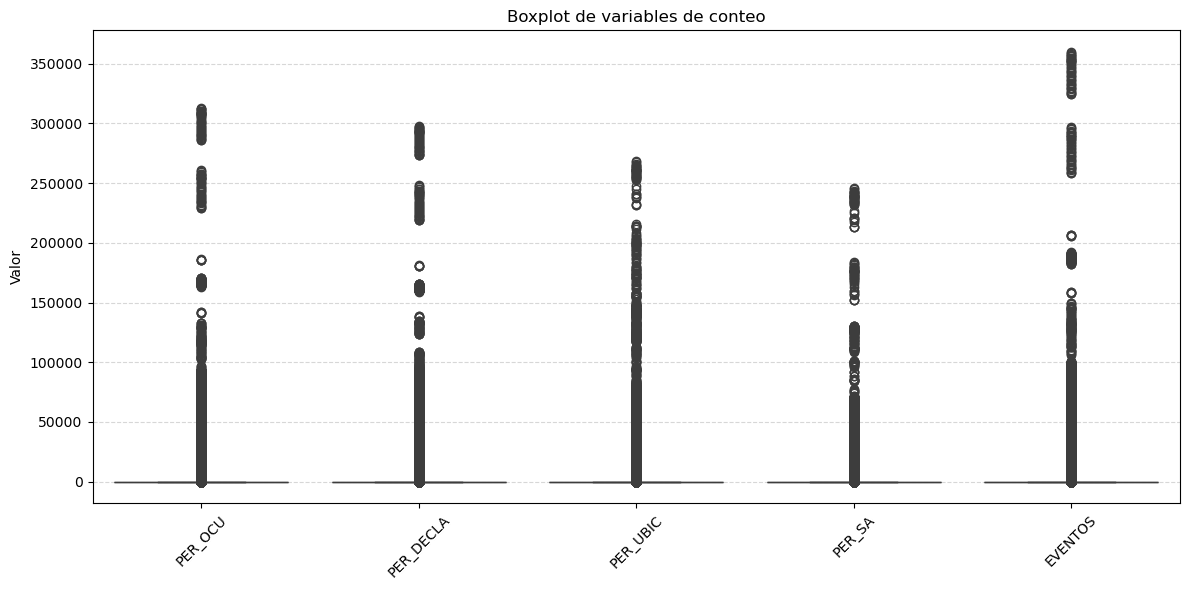

In [26]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[variables_conteo])
plt.title("Boxplot de variables de conteo")
plt.ylabel("Valor")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Listamos los grupos que hay en el dataset

In [30]:
#Obtener lista de grupos únicos
grupos = df.groupby(columnas_grupo).groups.keys()

# Convertir a lista para facilitar copia
grupos_lista = list(grupos)

# Convertimos a df para facilitar exportación
grupos_df = pd.DataFrame(grupos, columns=columnas_grupo)

# Cuántos grupos hay
print(f"Total de grupos: {len(grupos_lista)} \n")

# Ver los primeros 5 grupos
for g in grupos_lista[:5]:
    print(g)


Total de grupos: 95561 

(0, 'SIN DEFINIR', 1, 'Acto terrorista / Atentados / Combates / Enfrentamientos / Hostigamientos', 'Hombre', 'Gitano (RROM) (Acreditado RA)', 'Ninguna', 'entre 18 y 28')
(0, 'SIN DEFINIR', 1, 'Acto terrorista / Atentados / Combates / Enfrentamientos / Hostigamientos', 'Hombre', 'Gitano (RROM) (Acreditado RA)', 'Ninguna', 'entre 29 y 59')
(0, 'SIN DEFINIR', 1, 'Acto terrorista / Atentados / Combates / Enfrentamientos / Hostigamientos', 'Hombre', 'Gitano (RROM) (Acreditado RA)', 'Ninguna', 'entre 29 y 60')
(0, 'SIN DEFINIR', 1, 'Acto terrorista / Atentados / Combates / Enfrentamientos / Hostigamientos', 'Hombre', 'Gitano(a) ROM', 'Fisica', 'entre 29 y 59')
(0, 'SIN DEFINIR', 1, 'Acto terrorista / Atentados / Combates / Enfrentamientos / Hostigamientos', 'Hombre', 'Gitano(a) ROM', 'Fisica', 'entre 29 y 60')


In [31]:
# Paso 4: Exportar con la plantilla estándar
grupos_df.to_csv(
    path_or_buf='../data/processed/grupos_unicos.csv',
    sep=',',
    na_rep='',
    header=True,
    index=False,
    encoding='utf-8',
    quoting=csv.QUOTE_MINIMAL,
    lineterminator=os.linesep,
    quotechar='"',
    decimal='.',
    errors='strict'
)

## Ordenar por grupos y fechas  
Verificamos si existen patrones en los registros dentro de cada grupo.  
Esto nos ayuda a confirmar si los valores corresponden a **outliers reales** o a **conteos acumulados/por evento**.

In [33]:
# Ordenamos por grupos 
df_sorted = df.sort_values(by=columnas_grupo + ['FECHA_CORTE'])

df_sorted.head()

,FECHA_CORTE,COD_ESTADO_DEPTO,ESTADO_DEPTO,PARAM_HECHO,HECHO,SEXO,ETNIA,DISCAPACIDAD,CICLO_VITAL,PER_OCU,PER_DECLA,PER_UBIC,PER_SA,EVENTOS
2385948,28/02/2025,0,SIN DEFINIR,1,Acto terrorista / Atentados / Combates / Enfre...,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,0,1,0,0,0
1571594,29/02/2024,0,SIN DEFINIR,1,Acto terrorista / Atentados / Combates / Enfre...,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,0,1,0,0,0
1631003,29/02/2024,0,SIN DEFINIR,1,Acto terrorista / Atentados / Combates / Enfre...,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,0,1,0,0,0
1786739,30/04/2024,0,SIN DEFINIR,1,Acto terrorista / Atentados / Combates / Enfre...,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,0,1,0,0,0
1126368,30/06/2023,0,SIN DEFINIR,1,Acto terrorista / Atentados / Combates / Enfre...,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,0,1,0,0,0


In [34]:
# 👉 Si quieres inspeccionar un grupo en particular:
ejemplo = df_sorted.groupby(columnas_grupo).get_group(
    (5, "Antioquia", 5, "Desplazamiento forzado", "Mujer", "Ninguna", "Visual", "entre 18 y 28")
)



print(ejemplo[['FECHA_CORTE'] + variables_conteo].head(15))

        FECHA_CORTE  PER_OCU  PER_DECLA  PER_UBIC  PER_SA  EVENTOS
260379   28/02/2022      287        293       223     206      350
815596   28/02/2023      346        344       299     271      427
2383964  28/02/2025      351        347       247     219      447
1614793  29/02/2024      352        345       304     271      439
1674203  29/02/2024      352        345       304     271      439
337170   30/04/2022      288        295       236     218      353
938154   30/04/2023      347        344       299     271      429
1787879  30/04/2024      348        343       308     274      436
122789   30/06/2022      329        332       272     249      403
385141   30/06/2022      329        332       272     249      403
1134033  30/06/2023      348        346       307     279      436
1916461  30/06/2024      349        344       305     270      435
527617   30/09/2022      333        336       287     263      408
1309323  30/09/2023      355        351       309     276     

### 📊 Lo que muestran los datos (ejemplo del grupo elegido)

* Grupo: **Antioquia / Desplazamiento forzado / Mujer / Ninguna discapacidad / Visual / entre 18 y 28**
* Variables de conteo: `PER_OCU`, `PER_DECLA`, `PER_UBIC`, `PER_SA`, `EVENTOS`
* Fechas: todos los cortes son **últimos días de mes** (`28/02`, `30/04`, `30/06`, `30/09` …).
* Años: **2022 → 2023 → 2024 → 2025**.
* Hay duplicados exactos en algunos cortes (ejemplo: `29/02/2024` aparece dos veces con los mismos valores).


### 🔎 Posibles interpretaciones

1. **Estructura temporal regular**

   * Los cortes siempre son fin de mes → esto indica que el dataset **probablemente está diseñado como series mensuales** de cierre o corte administrativo.
   * No parece ser un registro "diario de eventos", sino una **consolidación mensual**.

2. **Tendencia general (acumulativo o no)**

   * Ejemplo `EVENTOS`:

     * 2022-02 → 350
     * 2023-02 → 427
     * 2024-02 → 439
     * 2025-02 → 447
   * 🔼 Esto sugiere un **comportamiento acumulativo**: el número sube con el tiempo y nunca se reinicia a cero.
   * Idem para `PER_OCU`, `PER_DECLA`, etc. → todos siguen una **línea ascendente suave**.

3. **Duplicados en la fuente**

   * El `29/02/2024` aparece **dos veces idénticas** → probablemente un error de carga, o que el reporte mensual fue exportado dos veces en tu dataset.
   * Esto deberías **depurarlo** (quedarte con uno solo).

4. **Variaciones pequeñas**

   * El crecimiento es bastante regular, con incrementos pequeños cada año.
   * Ejemplo: `EVENTOS` sube de 350 (2022) → 447 (2025). Un crecimiento del 27% en 3 años.
   * Eso refuerza que es un **conteo acumulado de víctimas registradas** (cada corte incluye lo anterior + lo nuevo).



### ✅ Conclusión preliminar

* Tus datos en este grupo parecen ser **conteos acumulativos** y no valores aislados.
* Los “outliers” que ves (ejemplo duplicados) no son outliers reales, sino **problemas de duplicación en la fuente**.
* El análisis de **diferencias entre fechas consecutivas** (`diff()`) sería más informativo que el valor absoluto → así obtienes la cantidad de nuevos casos reportados en cada mes/trimestre.

In [62]:
# Crear un diccionario para almacenar resultados
resumen_conteo = {}

for col in variables_conteo:
    # Frecuencia de cada valor
    vc = df[col].value_counts().sort_index()
    
    # Total de la variable
    total = df[col].sum()
    
    # Guardar ambos en el diccionario
    resumen_conteo[col] = {
        "Frecuencia de valores": vc,
        "Suma total": total
    }

# Mostrar resumen organizado
for col, info in resumen_conteo.items():
    print(f"\n🔢 Variable: {col}")
    print("-" * 40)
    print("📊 Value Counts:")
    print(info["Frecuencia de valores"])
    print(f"\n🧮 Suma total: {info['Suma total']}")



🔢 Variable: PER_OCU
----------------------------------------
📊 Value Counts:
PER_OCU
0         511074
1         637340
2         244960
3         137713
4          92783
           ...  
310767         1
311814         1
311955         1
312541         1
313180         1
Name: count, Length: 15696, dtype: int64

🧮 Suma total: 462326006

🔢 Variable: PER_DECLA
----------------------------------------
📊 Value Counts:
PER_DECLA
0         563604
1         609270
2         235709
3         133486
4          89580
           ...  
295624         1
296607         1
296703         1
297353         1
297993         1
Name: count, Length: 16123, dtype: int64

🧮 Suma total: 471544487

🔢 Variable: PER_UBIC
----------------------------------------
📊 Value Counts:
PER_UBIC
0         456844
1         662339
2         251032
3         143372
4          96633
           ...  
264679         2
265260         1
266059         1
267491         1
268244         1
Name: count, Length: 15756, dtype: int64

🧮

In [12]:
# Previsualización del impacto de los outliers
resumen_outliers = []

for col in variables_conteo:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    total = len(df)
    num_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

    resumen_outliers.append({
        'Variable': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Límite inferior': round(lower_bound, 2),
        'Límite superior': round(upper_bound, 2),
        'Outliers detectados': num_outliers,
        'Porcentaje Outliers': round((num_outliers / total) * 100, 2)
    })

resumen_df = pd.DataFrame(resumen_outliers)
display(resumen_df)


,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Outliers detectados,Porcentaje Outliers
0,PER_OCU,1.0,8.0,7.0,-9.5,18.5,418555,17.22
1,PER_DECLA,1.0,8.0,7.0,-9.5,18.5,418324,17.21
2,PER_UBIC,1.0,9.0,8.0,-11.0,21.0,394495,16.23
3,PER_SA,1.0,7.0,6.0,-8.0,16.0,418080,17.20
4,EVENTOS,1.0,9.0,8.0,-11.0,21.0,406537,16.72


In [14]:
resumen_df.to_csv(
    path_or_buf='../data/processed/resumen_outliers.csv',
    sep=',',
    na_rep='',
    header=True,
    index=False,
    encoding='utf-8',
    quoting=csv.QUOTE_MINIMAL,
    lineterminator=os.linesep,
    quotechar='"',
    decimal='.',
    errors='strict'
)

In [15]:
# Paso 1: Crear una máscara booleana para marcar outliers en cualquier columna
outlier_mask = pd.Series(False, index=df.index)

for col in variables_conteo:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Marcar como True los registros fuera del rango permitido
    outlier_mask |= (df[col] < lower_bound) | (df[col] > upper_bound)

In [16]:
# Paso 2: Guardar los registros eliminados (opcional pero recomendable)
df_outliers = df[outlier_mask].copy()

In [17]:
df_outliers.to_csv(
    path_or_buf='../data/processed/outliers.csv',
    sep=',',
    na_rep='',
    header=True,
    index=False,
    encoding='utf-8',
    quoting=csv.QUOTE_MINIMAL,
    lineterminator=os.linesep,
    quotechar='"',
    decimal='.',
    errors='strict'
)

In [18]:
# Paso 3: Filtrar el DataFrame conservando solo registros válidos
df = df[~outlier_mask].copy()

In [19]:
# Paso 4: Reporte rápido
print(f"Registros eliminados: {outlier_mask.sum()}")
print(f"Registros restantes: {len(df)}")

Registros eliminados: 510920
Registros restantes: 1920244


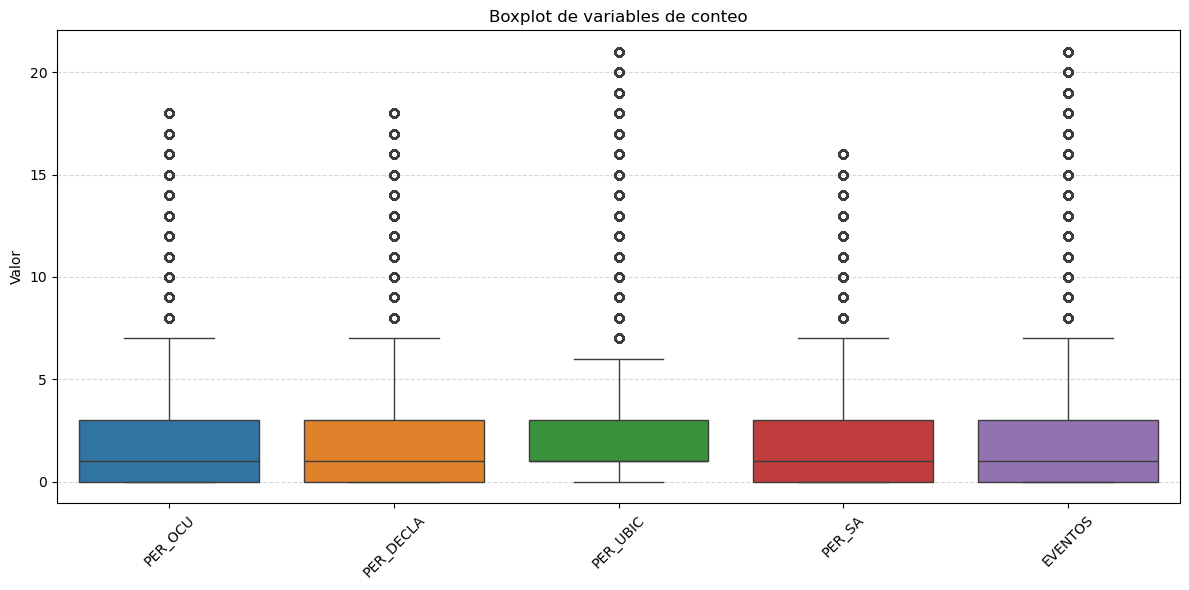

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[variables_conteo])
plt.title("Boxplot de variables de conteo")
plt.ylabel("Valor")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [21]:
# Crear un diccionario para almacenar resultados
resumen_conteo = {}

for col in variables_conteo:
    # Frecuencia de cada valor
    vc = df[col].value_counts().sort_index()
    
    # Total de la variable
    total = df[col].sum()
    
    # Guardar ambos en el diccionario
    resumen_conteo[col] = {
        "Frecuencia de valores": vc,
        "Suma total": total
    }

# Mostrar resumen organizado
for col, info in resumen_conteo.items():
    print(f"\n🔢 Variable: {col}")
    print("-" * 40)
    print("📊 Value Counts:")
    print(info["Frecuencia de valores"])
    print(f"\n🧮 Suma total: {info['Suma total']}")


🔢 Variable: PER_OCU
----------------------------------------
📊 Value Counts:
PER_OCU
0     489997
1     629969
2     238812
3     132846
4      88724
5      66370
6      50497
7      39307
8      33141
9      27574
10     22582
11     19811
12     17611
13     15000
14     13249
15     11090
16      9772
17      7860
18      6032
Name: count, dtype: int64

🧮 Suma total: 4884759

🔢 Variable: PER_DECLA
----------------------------------------
📊 Value Counts:
PER_DECLA
0     542853
1     605541
2     233352
3     131047
4      87532
5      64333
6      51771
7      38324
8      32329
9      25698
10     21878
11     19627
12     16525
13     13308
14     10810
15      8656
16      6932
17      5542
18      4186
Name: count, dtype: int64

🧮 Suma total: 4573622

🔢 Variable: PER_UBIC
----------------------------------------
📊 Value Counts:
PER_UBIC
0     455016
1     660205
2     248504
3     140713
4      94271
5      68887
6      51418
7      41642
8      32975
9      27009
10     22399
1

In [14]:
# Paso 2: Agrupar y sumar valores de conteo
df = df.groupby(columnas_grupo, as_index=False)[variables_conteo].sum()

In [15]:
# Paso 4: Validar que no queden NaN
print("¿Quedan NaN después del reemplazo?")
print(df[variables_conteo].isna().sum())

¿Quedan NaN después del reemplazo?
PER_OCU      0
PER_DECLA    0
PER_UBIC     0
PER_SA       0
EVENTOS      0
dtype: int64


# Generacion de COD_RPT de victimas
En esta seccion se genera el COD_RPT de las victimas para su posterior uso en la generacion de las primary keys.

In [16]:
# Asegurarse de que el índice sea limpio, secuencial y comience desde 0
df = df.reset_index(drop=True)

# Crear columna 'COD_RPT' como ID incremental comenzando desde 1
df['COD_RPT'] = df.index + 1

# Reordenar columnas para que 'COD_RPT' esté al inicio
df = df[['COD_RPT'] + [col for col in df.columns if col != 'COD_RPT']]


# Muestra del dataset de víctimas limpio 

In [22]:
df.head(20)

,FECHA_CORTE,COD_ESTADO_DEPTO,ESTADO_DEPTO,PARAM_HECHO,HECHO,SEXO,ETNIA,DISCAPACIDAD,CICLO_VITAL,PER_OCU,PER_DECLA,PER_UBIC,PER_SA,EVENTOS
0,2022/03/31 00:00:00.000000000,13,Bolivar,5,Desplazamiento forzado,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,3,4,3,3,3
1,2022/02/28 00:00:00.000000000,20,Cesar,5,Desplazamiento forzado,Mujer,Raizal del Archipielago de San Andres y Provid...,Multiple,entre 60 y 110,1,0,0,0,1
2,2022/04/30 00:00:00.000000000,18,Caqueta,5,Desplazamiento forzado,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 29 y 60,2,0,0,0,2
3,2022/05/31 00:00:00.000000000,95,Guaviare,5,Desplazamiento forzado,Hombre,Negro(a) o Afrocolombiano(a),Fisica,entre 60 y 110,11,7,4,4,12
4,2022/04/30 00:00:00.000000000,18,Caqueta,2,Amenaza,Hombre,Indigena (Acreditado RA),Por Establecer,entre 12 y 17,1,1,1,1,1
6,2022/02/28 00:00:00.000000000,25,Cundinamarca,20,Sin informacion,Mujer,Indigena,Ninguna,entre 29 y 60,1,0,3,3,1
7,2022/03/31 00:00:00.000000000,99,Vichada,4,Desaparición forzada,No Informa,Ninguna,Ninguna,ND,0,1,0,0,0
8,2022/01/31 00:00:00.000000000,18,Caqueta,2,Amenaza,Hombre,Gitano(a) ROM,Por Establecer,entre 18 y 28,1,1,0,0,2
9,2022/01/31 00:00:00.000000000,66,Risaralda,6,Homicidio,Hombre,Indigena,Fisica,entre 29 y 60,2,1,1,1,2
10,2022/05/31 00:00:00.000000000,44,La Guajira,5,Desplazamiento forzado,LGBTI,Ninguna,Multiple,entre 29 y 60,0,1,0,0,0


In [23]:
df.tail(20)

,FECHA_CORTE,COD_ESTADO_DEPTO,ESTADO_DEPTO,PARAM_HECHO,HECHO,SEXO,ETNIA,DISCAPACIDAD,CICLO_VITAL,PER_OCU,PER_DECLA,PER_UBIC,PER_SA,EVENTOS
2431136,28/02/2025,81,Arauca,5,Desplazamiento forzado,Hombre,Negro(a) o Afrocolombiano(a) (Acreditado RA),Multiple,entre 18 y 28,1,0,0,0,1
2431137,28/02/2025,76,Valle del Cauca,11,Abandono o Despojo Forzado de Tierras,Mujer,Negro(a) o Afrocolombiano(a),Intelectual,entre 18 y 28,1,0,1,1,1
2431139,28/02/2025,0,SIN DEFINIR,5,Desplazamiento forzado,Mujer,Ninguna,Auditiva,entre 0 y 5,0,0,15,9,0
2431140,28/02/2025,41,Huila,2,Amenaza,Mujer,Ninguna,Auditiva,entre 18 y 28,12,7,11,11,13
2431142,28/02/2025,41,Huila,12,Perdida de Bienes Muebles o Inmuebles,Mujer,Ninguna,Auditiva,entre 6 y 11,0,0,1,1,0
2431143,28/02/2025,52,Nariño,14,Lesiones Personales Psicologicas,Hombre,Ninguna,Multiple,entre 60 y 110,10,16,18,16,10
2431145,28/02/2025,20,Cesar,8,Secuestro,Mujer,Ninguna,Ninguna,entre 12 y 17,4,3,4,4,4
2431146,28/02/2025,0,SIN DEFINIR,3,Delitos contra la libertad y la integridad sex...,Hombre,Ninguna,Fisica,entre 18 y 28,1,0,0,0,1
2431147,28/02/2025,11,"Bogota, D.C.",7,"Minas Antipersonal, Munición sin Explotar y Ar...",Mujer,Negro(a) o Afrocolombiano(a),Psicosocial (Mental),entre 29 y 59,0,1,0,0,0
2431149,28/02/2025,8,Atlantico,12,Perdida de Bienes Muebles o Inmuebles,Hombre,Ninguna,Auditiva,entre 29 y 59,1,1,1,1,1


In [111]:
# Crear un diccionario para almacenar resultados
resumen_conteo = {}

for col in variables_conteo:
    # Frecuencia de cada valor
    vc = df[col].value_counts().sort_index()
    
    # Total de la variable
    total = df[col].sum()
    
    # Guardar ambos en el diccionario
    resumen_conteo[col] = {
        "Frecuencia de valores": vc,
        "Suma total": total
    }

# Mostrar resumen organizado
for col, info in resumen_conteo.items():
    print(f"\n🔢 Variable: {col}")
    print("-" * 40)
    print("📊 Value Counts:")
    print(info["Frecuencia de valores"])
    print(f"\n🧮 Suma total: {info['Suma total']}")



🔢 Variable: PER_OCU
----------------------------------------
📊 Value Counts:
PER_OCU
0      21630
1        874
2        532
3        680
4       1124
       ...  
700        1
708        1
720        1
727        1
730        1
Name: count, Length: 668, dtype: int64

🧮 Suma total: 4884759

🔢 Variable: PER_DECLA
----------------------------------------
📊 Value Counts:
PER_DECLA
0      23624
1        863
2        485
3        670
4       1057
       ...  
697        1
700        1
701        1
723        2
732        1
Name: count, Length: 654, dtype: int64

🧮 Suma total: 4573622

🔢 Variable: PER_UBIC
----------------------------------------
📊 Value Counts:
PER_UBIC
0      14461
1       1686
2       1077
3       1277
4       1551
       ...  
714        1
715        1
732        1
743        1
770        1
Name: count, Length: 639, dtype: int64

🧮 Suma total: 4657671

🔢 Variable: PER_SA
----------------------------------------
📊 Value Counts:
PER_SA
0      16606
1       1757
2       145

# Exportamos los datos limpios a un archivo CSV
Se exporta el archivo CSV con los datos limpios en en ´/data/processed/victimas_por_hechos_departamental_20250416.csv´ para su posterior análisis

In [112]:
df.to_csv(
    path_or_buf='../data/processed/victimas_por_hechos_departamental_20250416.csv',
    sep=',',
    na_rep='',
    header=True,
    index=False,
    encoding='utf-8',
    quoting=csv.QUOTE_MINIMAL,
    lineterminator=os.linesep,
    quotechar='"',
    decimal='.',
    errors='strict'
)